# 屈折を考慮して、見かけの位置でGaussianを移動させ、レンダリングする


In [2]:
import os
import torch
import numpy as np
from plyfile import PlyData
from gsplat import rasterization
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

In [3]:

import sys
sys.path.append('..')  # Adjust the path as necessary to locate the 'mine' module
from mine.read_transformers import readNerfSyntheticCameras, fov2focal
from pathlib import Path

nerf_dataset_path = os.path.abspath(os.path.join("..", "data", "transformers"))

train_cams, test_cams = readNerfSyntheticCameras(nerf_dataset_path, white_background=True, extension=".png", eval_mode=True)

print(len(train_cams), "training cameras")
print(len(test_cams), "test cameras")

# 例: 取り出し
for cam in train_cams[:1]:
    print("uid=", cam.uid)
    print("R=", cam.R)
    print("T=", cam.T)
    print("FovX(deg)=", np.degrees(cam.FovX))
    print("FovY(deg)=", np.degrees(cam.FovY))
    print("image_name=", cam.image_name)
    print("image size=", (cam.width, cam.height))
    print("---")


Reading Training Transforms...
64 training cameras
0 test cameras
uid= 0
R= [[ 1. -0. -0.]
 [ 0. -1. -0.]
 [ 0. -0. -1.]]
T= [ 16.804981 -16.804981  20.      ]
FovX(deg)= 39.597755335771296
FovY(deg)= 39.597755335771296
image_name= 0000
image size= (1600, 1600)
---


In [4]:
# 0番目カメラを取り出す
cam = train_cams[30]
width, height = cam.width//4, cam.height//4
# width, height = cam.width//2, cam.height//2
# width, height = cam.width, cam.height

# f_x, f_y を計算
f_x = fov2focal(cam.FovX, width)   # 横幅に対する焦点距離
f_y = fov2focal(cam.FovY, height)  # 縦幅に対する焦点距離

# 光学中心 cx, cy (画像中心と仮定)
cx = width  / 2.0
cy = height / 2.0

# Intrinsics 行列
K = np.array([
    [f_x,   0,   cx],
    [  0, f_y,   cy],
    [  0,   0,   1 ]
], dtype=np.float32)

print("K =\n", K)
# 4x4 のワールド→カメラ変換 (Extrinsic) を作る
W2C = np.eye(4, dtype=np.float32)
W2C[:3, :3] = cam.R  # cam.R はすでに転置済みの場合あり; それは readNerfSyntheticInfo の仕様
W2C[:3,  3] = cam.T

print("W2C =\n", W2C)

# ライブラリに合った形に reshape/unsqueeze するなど
viewmats = torch.from_numpy(W2C)[None, :, :].to(device)  # 1カメラ分の4x4行列をCUDAへ
Ks       = torch.from_numpy(K)[None, :, :].to(device) # 1カメラ分の3x3行列をCUDAへ

K =
 [[555.55554   0.      200.     ]
 [  0.      555.55554 200.     ]
 [  0.        0.        1.     ]]
W2C =
 [[ 1.        -0.        -0.        -4.2012453]
 [ 0.        -1.        -0.         8.402491 ]
 [ 0.        -0.        -1.        20.       ]
 [ 0.         0.         0.         1.       ]]


In [5]:
# path of ply file
file_path = os.path.abspath(os.path.join(os.path.expanduser("~"), "OneDrive", "3d_map_data", "20250318_simple_river_wo_surface_COS", "result", "transformers_20250318-173258", "ply", "point_cloud_29999.ply"))

from mine.loader import initialize_model_from_ply_file
# get Gaussian model from ply file
gs_model = initialize_model_from_ply_file(file_path, device=device)

In [6]:
gs_model

VanillaGaussianModel(
  (gaussians): ParameterDict(
      (means): Parameter containing: [torch.cuda.FloatTensor of size 1000000x3 (cuda:0)]
      (opacities): Parameter containing: [torch.cuda.FloatTensor of size 1000000x1 (cuda:0)]
      (scales): Parameter containing: [torch.cuda.FloatTensor of size 1000000x3 (cuda:0)]
      (rotations): Parameter containing: [torch.cuda.FloatTensor of size 1000000x4 (cuda:0)]
      (shs): Parameter containing: [torch.cuda.FloatTensor of size 1000000x16x3 (cuda:0)]
  )
)

In [7]:
# get each parameters as tensor from Gaussian model  torch.from_numpy
means     = gs_model.gaussians["means"]      # shape: [N, 3]
scales    = gs_model.gaussians["scales"]     # shape: [N, 3]
quats     = gs_model.gaussians["rotations"]  # shape: [N, 4]
opacities = gs_model.gaussians["opacities"].squeeze(-1)   # shape: (N,)
colors    = gs_model.gaussians["shs"]        # shape: [N, 16, 3]



# Refractionを考慮して座標変換

In [8]:
def transform_gaussian_point(point, cam_center, n=1.33, plane=0, atol=1e-8):
    """
    1点のGaussian中心 (world座標) を、カメラ中心および水面 z=plane を基準に屈折補正する。
    point: (x,y,z)
    cam_center: (x0,y0,H) カメラ位置（world座標）
    n: 屈折率（例: 水の場合 1.33）
    """
    # カメラ中心とのオフセット
    x0, y0, _ = cam_center
    H = cam_center[2]
    dx = point[0] - x0
    dy = point[1] - y0
    # 水面 z=plane に対する深さ。水中であれば h は負になる想定
    h = point[2] - plane  
    angle = np.arctan2(dy, dx)
    r = np.sqrt(dx**2 + dy**2)
    
    n2 = n**2
    H2 = H**2
    # 四次方程式の係数 (sに関する方程式)
    a4 = 1 - n2
    a3 = 2 * r * (n2 - 1)
    a2 = h**2 + (1 - n2)*r**2 - n2 * H2
    a1 = 2 * n2 * r * H2
    a0 = - H2 * n2 * r**2
    
    coeffs = [a4, a3, a2, a1, a0]
    s_roots = np.roots(coeffs)
    xs = 0  # デフォルト値
    # 実数解かつ s < r となる解を採用
    for s in s_roots:
        if np.abs(s.imag) < atol and s.real < r:
            xs = s.real
            break

    # 入射角 theta0, 屈折角 theta1 の計算
    theta0 = np.arcsin(xs / np.hypot(H, xs))
    theta1 = np.arcsin((r - xs) / np.hypot(-h, r - xs))
    
    # 補正量の算出
    ra = h * (n2 - 1) * (np.tan(theta1)**3)
    A = (1 - n2 * (np.sin(theta1)**2))**1.5
    za = h * A / (n * (np.cos(theta1)**3))
    
    # 水平方向の補正 (カメラ中心からのずれ)
    dx_app = ra * np.cos(angle)
    dy_app = ra * np.sin(angle)
    
    # 見かけ上の位置 (world座標)
    new_x = x0 + dx_app
    new_y = y0 + dy_app
    new_z = plane + za
    
    return np.array([new_x, new_y, new_z])
    
    
    

In [9]:
def transform_all_gaussians(means_np, cam_center, n=1.33, plane=0, atol=1e-8):
    """
    全てのGaussian中心 (numpy 配列, shape: [N,3]) に対して屈折変換を適用する。
    """
    new_means = []
    for i in range(means_np.shape[0]):
        new_point = transform_gaussian_point(means_np[i], cam_center, n, plane, atol)
        new_means.append(new_point)
    return np.stack(new_means, axis=0)

In [10]:
# --- メイン処理 ---
# 元のGaussian中心を numpy 配列に変換
means_np = means.cpu().detach().numpy()
# カメラ中心 (cam.T) は既に world 座標。必要に応じ numpy 配列に変換
cam_center_np = cam.T if isinstance(cam.T, np.ndarray) else cam.T.cpu().detach().numpy()

# 全Gaussianに対して屈折補正を適用
transformed_means_np = transform_all_gaussians(means_np, cam_center_np, n=1.33, plane=0, atol=1e-8)

# 変換後のGaussian中心を torch.Tensor に変換して device に配置
transformed_means = torch.from_numpy(transformed_means_np).to(device).float()



In [11]:
# ここで、もし元のモデルを更新したい場合は以下のように置き換えます
gs_model.gaussians["means"] = transformed_means

In [12]:
# 補正後の Gaussian を用いてレンダリング
rgb_image, alpha, metadata = rasterization(
    transformed_means,
    quats,
    scales,
    opacities,
    colors,
    viewmats,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)

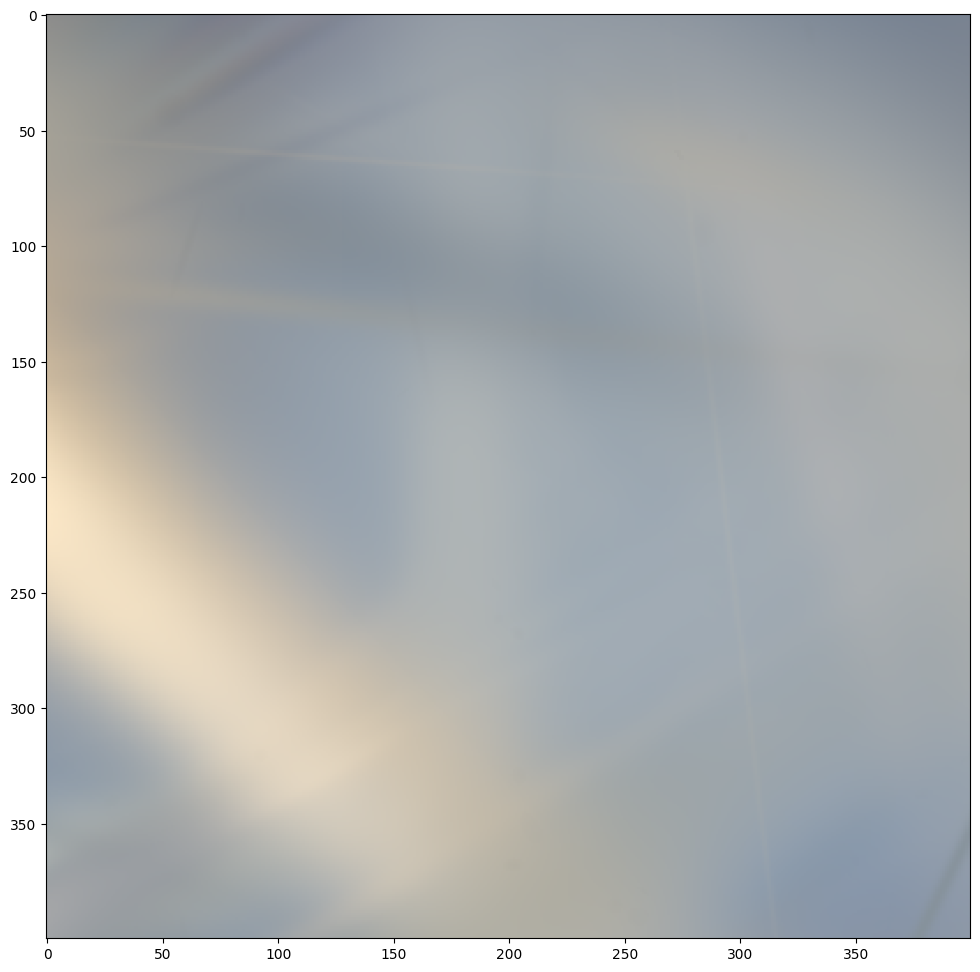

In [13]:
# Display the rendered image.
display_image = rgb_image.squeeze().cpu().detach().numpy()
plt.imshow(display_image)
# plt.axis("off")


In [ ]:
# # save ply file
# from gsplat.utils import save_ply
# ply_dir = os.path.curdir
# step = 0
# save_ply(gs_model.gaussians, f"{ply_dir}/point_cloud_{step}.ply", None)

Saving ply to ./point_cloud_0.ply
